<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/phase2_energy_forecasting_acf_pacf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PJM Hourly Energy Demand Forecasting
## Phase 2 Project — SARIMA & ETS with Walk-Forward Validation

**Dataset:** [PJM Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)  
Download `AEP_hourly.csv` from Kaggle and place it in the same folder as this notebook.

**What this notebook covers:**
1. Load & explore the data (EDA)
2. Stationarity testing & differencing
3. ACF / PACF analysis → SARIMA order selection
4. Fit SARIMA and ETS on daily-aggregated data
5. Walk-forward (rolling-origin) cross-validation
6. Residual diagnostics
7. Results comparison table
8. Where classical models break down → motivation for Phase 3

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.7 MB/s eta 0:00:00


## 0. Install & import

In [ ]:
# Install dependencies (run once)
# !pip install statsmodels pmdarima pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox

import pmdarima as pm   # pip install pmdarima

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## 1. Load & explore the data

In [ ]:
# ---------- Load ----------
df_raw = pd.read_csv('/content/AEP_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df_raw = df_raw.sort_index()
df_raw.columns = ['demand_mw']

print(f"Shape         : {df_raw.shape}")
print(f"Date range    : {df_raw.index.min()} → {df_raw.index.max()}")
print(f"Missing hours : {df_raw.isnull().sum().values[0]}")
print(f"\nSample rows:")
df_raw.head()

Shape         : (121273, 1)
Date range    : 2004-10-01 01:00:00 → 2018-08-03 00:00:00
Missing hours : 0

Sample rows:


,demand_mw
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


Daily series  : 5055 days


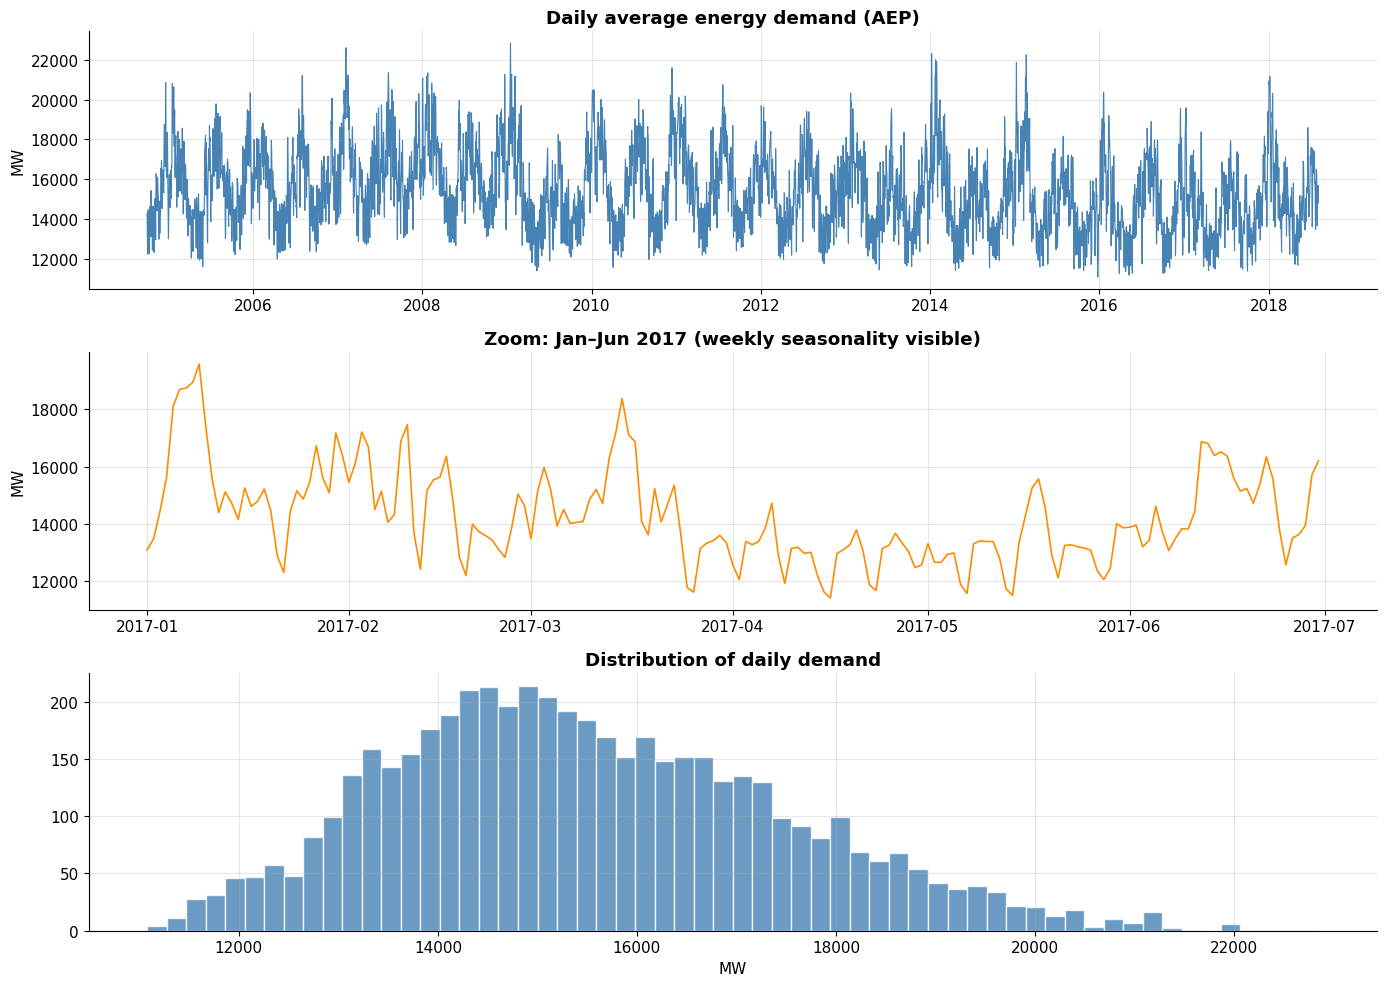

In [ ]:
# ---------- Aggregate to daily (makes SARIMA tractable) ----------
# NOTE: We lose intraday patterns here — that is intentional for Phase 2.
# Phase 3 will work on hourly data directly.
daily = df_raw['demand_mw'].resample('D').mean().dropna()

print(f"Daily series  : {len(daily)} days")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Full series
axes[0].plot(daily, color='steelblue', linewidth=0.8)
axes[0].set_title('Daily average energy demand (AEP)', fontweight='bold')
axes[0].set_ylabel('MW')

# Zoom: 6 months to see weekly pattern
zoom = daily['2017-01':'2017-06']
axes[1].plot(zoom, color='darkorange', linewidth=1.2)
axes[1].set_title('Zoom: Jan–Jun 2017 (weekly seasonality visible)', fontweight='bold')
axes[1].set_ylabel('MW')

# Distribution
axes[2].hist(daily, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribution of daily demand', fontweight='bold')
axes[2].set_xlabel('MW')

plt.tight_layout()
plt.show()

# --- Study note ---
# OBSERVE: Do you see trend? Does variance seem stable?
# Look for: annual seasonality (summer/winter peaks), weekly dips (weekends)

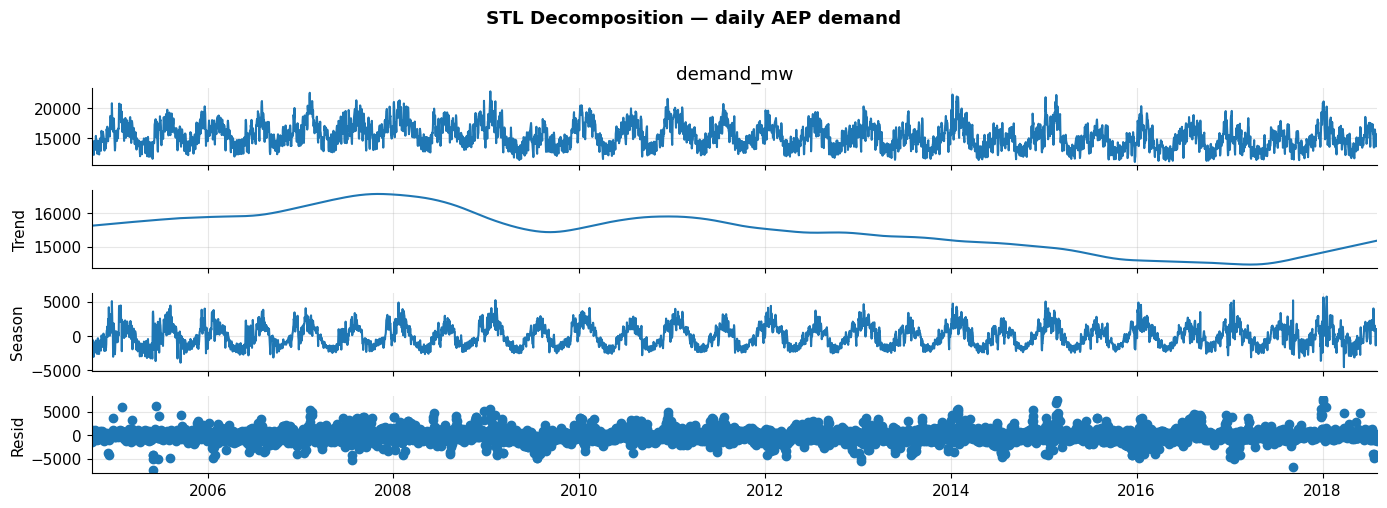

In [ ]:
# ---------- STL Decomposition ----------
# STL separates: trend + seasonality + residual
stl = STL(daily, period=365, robust=True)
stl_result = stl.fit()
stl_result.plot()
plt.suptitle('STL Decomposition — daily AEP demand', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Study note ---
# QUESTION: Is the trend strong or weak? What season has peak demand?
# Are residuals white noise or do they show structure?

---
## 2. Stationarity testing

In [ ]:
def stationarity_report(series: pd.Series, name: str = 'series'):
    """Run ADF and KPSS tests and print a clean report."""
    print(f"\n{'='*50}")
    print(f"Stationarity report: {name}")
    print(f"{'='*50}")

    # ADF — H0: series has a unit root (non-stationary)
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    print(f"\nADF test")
    print(f"  Statistic : {adf_stat:.4f}")
    print(f"  p-value   : {adf_p:.4f}  {'✅ stationary (reject H0)' if adf_p < 0.05 else '❌ non-stationary (fail to reject H0)'}")
    print(f"  Crit vals : {adf_crit}")

    # KPSS — H0: series IS stationary (opposite null!)
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS test")
    print(f"  Statistic : {kpss_stat:.4f}")
    print(f"  p-value   : {kpss_p:.4f}  {'❌ non-stationary (reject H0)' if kpss_p < 0.05 else '✅ stationary (fail to reject H0)'}")

    # Agreement
    adf_stat_flag = adf_p < 0.05
    kpss_stat_flag = kpss_p >= 0.05
    agreement = adf_stat_flag and kpss_stat_flag
    print(f"\n  → Both tests agree: {'STATIONARY ✅' if agreement else 'NON-STATIONARY ❌ (difference required)'}")

# Test raw series
stationarity_report(daily, 'Raw daily demand')

# Test first difference
daily_diff1 = daily.diff().dropna()
stationarity_report(daily_diff1, 'First-differenced')

# Test seasonal difference (lag-7)
daily_diff_s = daily.diff(7).dropna()
stationarity_report(daily_diff_s, 'Seasonal-differenced (lag-7)')

# --- Study note ---
# The d parameter in SARIMA(p,d,q) = how many first-differences you applied
# The D parameter = how many seasonal-differences you applied
# Typically d=1, D=1 for most real series


Stationarity report: Raw daily demand

ADF test
  Statistic : -7.4875
  p-value   : 0.0000  ✅ stationary (reject H0)
  Crit vals : {'1%': np.float64(-3.4316522779278373), '5%': np.float64(-2.8621154666284063), '10%': np.float64(-2.5670763214801435)}

KPSS test
  Statistic : 1.7210
  p-value   : 0.0100  ❌ non-stationary (reject H0)

  → Both tests agree: NON-STATIONARY ❌ (difference required)

Stationarity report: First-differenced

ADF test
  Statistic : -16.2223
  p-value   : 0.0000  ✅ stationary (reject H0)
  Crit vals : {'1%': np.float64(-3.4316530564249215), '5%': np.float64(-2.8621158105649367), '10%': np.float64(-2.567076504570864)}

KPSS test
  Statistic : 0.0115
  p-value   : 0.1000  ✅ stationary (fail to reject H0)

  → Both tests agree: STATIONARY ✅

Stationarity report: Seasonal-differenced (lag-7)

ADF test
  Statistic : -12.9749
  p-value   : 0.0000  ✅ stationary (reject H0)
  Crit vals : {'1%': np.float64(-3.431654355990492), '5%': np.float64(-2.862116384706994), '10%': 

---
## 3. ACF / PACF analysis → choose SARIMA orders

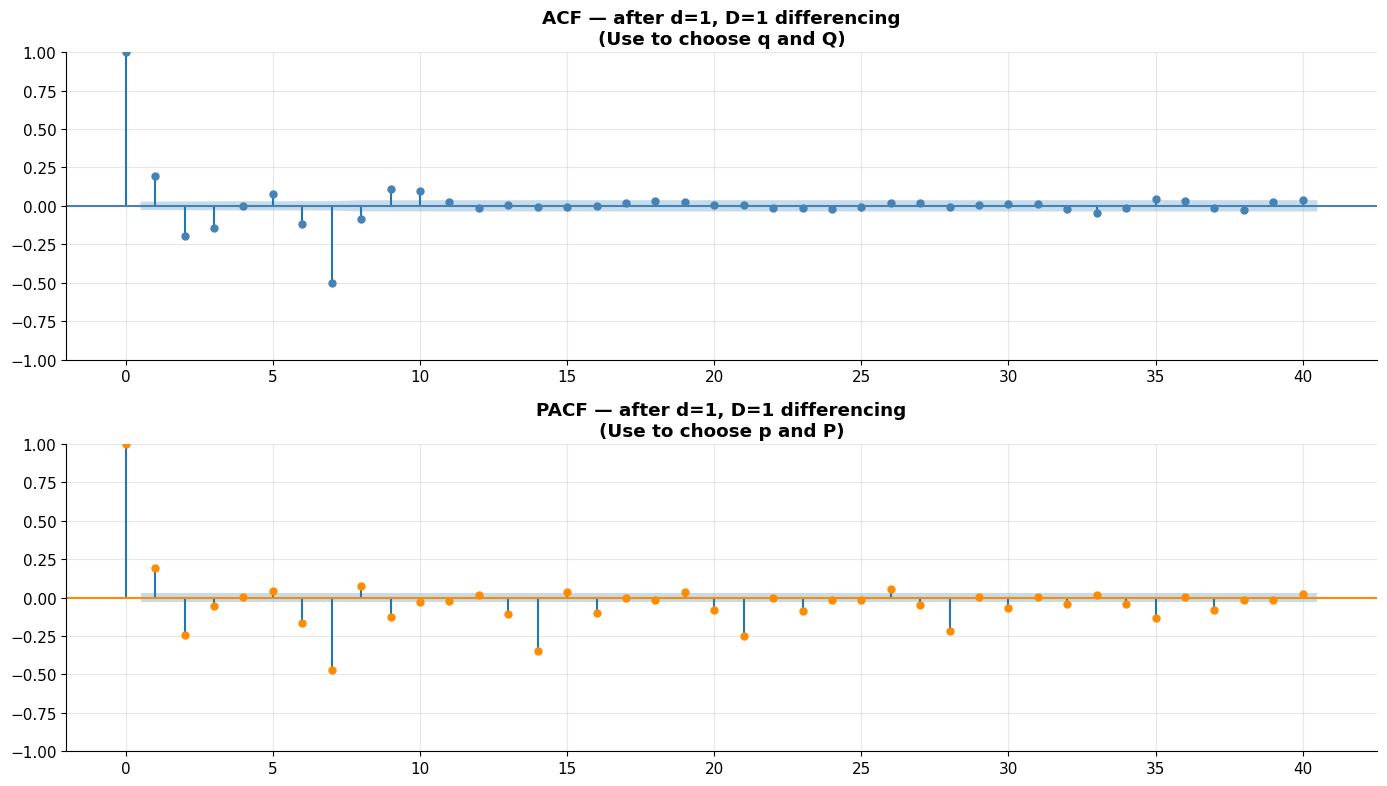

In [ ]:
# Use the once-differenced series for ACF/PACF inspection
# (series should be stationary before reading ACF/PACF for ARIMA order selection)
series_for_acf = daily.diff().diff(7).dropna()  # d=1, D=1

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(series_for_acf, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — after d=1, D=1 differencing\n(Use to choose q and Q)', fontweight='bold')

plot_pacf(series_for_acf, lags=40, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('PACF — after d=1, D=1 differencing\n(Use to choose p and P)', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Study note: how to read these ---
# ACF tells you about MA (q, Q):
#   - Sharp cut-off after lag k → q = k (non-seasonal)
#   - Sharp cut-off after lag 7, 14 → Q = 1 (seasonal, m=7)
# PACF tells you about AR (p, P):
#   - Sharp cut-off after lag k → p = k (non-seasonal)
#   - Sharp cut-off after lag 7, 14 → P = 1 (seasonal)
# Slow decay in ACF → AR process. Slow decay in PACF → MA process.

In [ ]:
# ---------- auto_arima: automated order selection ----------
# Use this AFTER forming your own guess from the plots above.
# Compare its suggestion to yours — disagreement is a learning moment!

# Use a subset for speed (auto_arima is slow on large series)
train_auto = daily[-365*3:]   # last 3 years

print("Running auto_arima (this may take 1–3 minutes)...")
auto_model = pm.auto_arima(
    train_auto,
    m=7,                  # weekly seasonality
    seasonal=True,
    d=1, D=1,             # fix differencing orders (from stationarity tests)
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True          # much faster than exhaustive search
)

print(f"\nauto_arima chose: {auto_model.order} x {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")
print("\n--- auto_arima summary ---")
print(auto_model.summary())

Running auto_arima (this may take 1–3 minutes)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=18213.188, Time=0.13 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=17854.260, Time=1.79 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=2.52 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=18144.344, Time=0.25 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=17739.072, Time=5.09 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=6.06 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=1.86 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=17800.719, Time=0.42 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=17680.638, Time=4.26 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=17796.260, Time=1.38 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=5.92 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=2.95 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=17671.257, Time=4.93 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=17788.408, Time=1.69 sec

---
## 4. Fit SARIMA and ETS

In [ ]:
# ---------- Train / test split ----------
# Use the last 90 days as test set; everything before = training
TEST_DAYS = 90

train = daily[:-TEST_DAYS]
test  = daily[-TEST_DAYS:]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)")
print(f"Test : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)")

Train: 2004-10-01 → 2018-05-05 (4965 days)
Test : 2018-05-06  → 2018-08-03  (90 days)


In [ ]:
# ---------- SARIMA ----------
# Use orders from auto_arima (or your manual selection from ACF/PACF)
SARIMA_ORDER         = auto_model.order            # (p, d, q)
SARIMA_SEASONAL_ORDER = auto_model.seasonal_order   # (P, D, Q, m)

print(f"Fitting SARIMA{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER}...")
sarima_fit = SARIMAX(
    train,
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("Done!")
print(sarima_fit.summary())

Fitting SARIMA(3, 1, 0)x(2, 1, 0, 7)...
Done!
                                     SARIMAX Results                                     
Dep. Variable:                         demand_mw   No. Observations:                 4965
Model:             SARIMAX(3, 1, 0)x(2, 1, 0, 7)   Log Likelihood              -40155.604
Date:                           Mon, 08 Jun 2026   AIC                          80323.208
Time:                                   22:56:48   BIC                          80362.239
Sample:                               10-01-2004   HQIC                         80336.896
                                    - 05-05-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2086      0.012     17.640      0.000       0.185       0.2

In [ ]:
# ---------- ETS (Holt-Winters Exponential Smoothing) ----------
# trend='add'     → additive trend (linear)
# seasonal='mul'  → multiplicative seasonality (variance grows with level)
#                   Try 'add' and compare AIC — use whichever is lower
print("Fitting ETS (Holt-Winters)...")
ets_fit = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=7,   # weekly
    damped_trend=True     # prevents trend from exploding at long horizons
).fit(optimized=True)

print("Done!")
print(f"ETS AIC  : {ets_fit.aic:.2f}")
print(f"Alpha (level)   : {ets_fit.params['smoothing_level']:.4f}")
print(f"Beta  (trend)   : {ets_fit.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal): {ets_fit.params['smoothing_seasonal']:.4f}")
# --- Study note ---
# Alpha close to 1 → model trusts recent values heavily
# Gamma close to 0 → seasonal pattern changes very slowly (stable seasonality)

Fitting ETS (Holt-Winters)...
Done!
ETS AIC  : 65807.63
Alpha (level)   : 1.0000
Beta  (trend)   : 0.0000
Gamma (seasonal): 0.0000


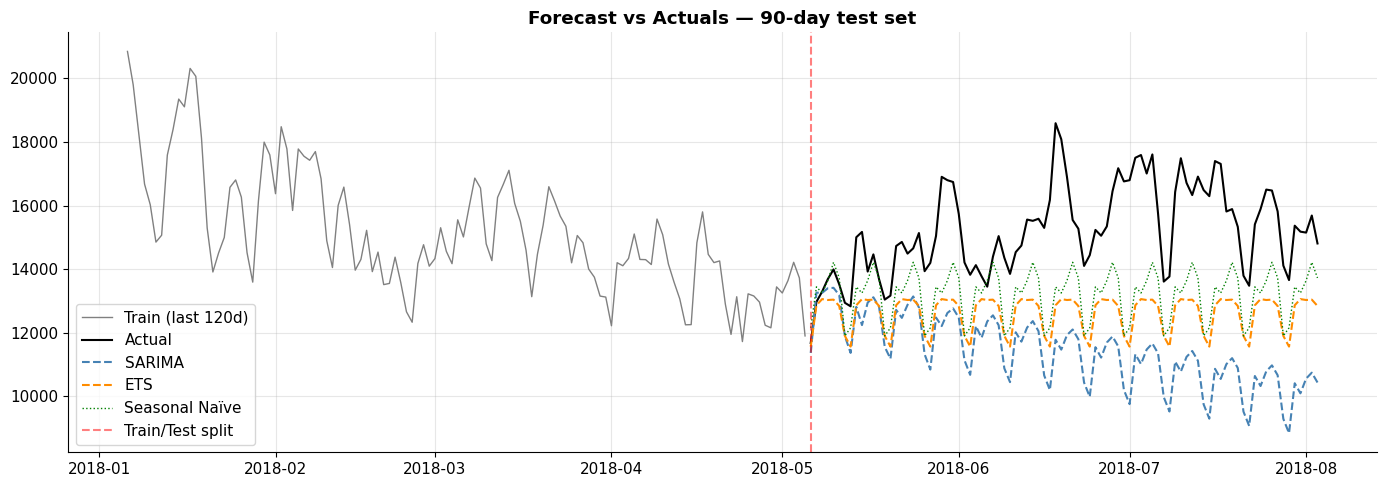

In [ ]:
# ---------- Point forecasts over test set ----------
sarima_forecast = sarima_fit.forecast(steps=TEST_DAYS)
ets_forecast    = ets_fit.forecast(steps=TEST_DAYS)
naive_forecast  = pd.Series(
    [train[-7:].values[i % 7] for i in range(TEST_DAYS)],
    index=test.index
)  # seasonal naïve: repeat last week

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-120:], color='gray', label='Train (last 120d)', linewidth=1)
ax.plot(test,          color='black', label='Actual', linewidth=1.5)
ax.plot(sarima_forecast, color='steelblue', label='SARIMA', linewidth=1.5, linestyle='--')
ax.plot(ets_forecast,    color='darkorange', label='ETS', linewidth=1.5, linestyle='--')
ax.plot(naive_forecast,  color='green', label='Seasonal Naïve', linewidth=1, linestyle=':')
ax.axvline(test.index[0], color='red', linestyle='--', alpha=0.5, label='Train/Test split')
ax.set_title('Forecast vs Actuals — 90-day test set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Walk-forward (rolling-origin) validation

In [ ]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def walk_forward_validation(
    series: pd.Series,
    n_test_windows: int = 8,
    horizon: int = 7,
    sarima_order: tuple = (1, 1, 1),
    sarima_seasonal_order: tuple = (1, 1, 1, 7),
):
    """
    Rolling-origin cross-validation for SARIMA and ETS.

    At each fold:
      - Train on all data up to cut-off
      - Forecast `horizon` days ahead
      - Record MAE, RMSE, MAPE
      - Slide the cut-off forward by `horizon` days

    This prevents data leakage — the model NEVER sees future data during training.
    """
    total_len   = len(series)
    test_size   = n_test_windows * horizon
    min_train   = total_len - test_size

    results = []

    for fold in range(n_test_windows):
        cutoff    = min_train + fold * horizon
        train_ser = series.iloc[:cutoff]
        test_ser  = series.iloc[cutoff: cutoff + horizon]

        fold_date = train_ser.index[-1].date()
        print(f"  Fold {fold+1}/{n_test_windows} | Train ends: {fold_date} | Forecast {horizon} days")

        # --- SARIMA ---
        try:
            sar = SARIMAX(
                train_ser,
                order=sarima_order,
                seasonal_order=sarima_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            sarima_pred = sar.forecast(steps=horizon).values
        except Exception as e:
            print(f"    SARIMA failed: {e}")
            sarima_pred = np.full(horizon, np.nan)

        # --- ETS ---
        try:
            ets = ExponentialSmoothing(
                train_ser,
                trend='add', seasonal='mul',
                seasonal_periods=7, damped_trend=True
            ).fit(optimized=True)
            ets_pred = ets.forecast(steps=horizon).values
        except Exception as e:
            print(f"    ETS failed: {e}")
            ets_pred = np.full(horizon, np.nan)

        # --- Seasonal Naïve ---
        last_week   = train_ser[-7:].values
        naive_pred  = np.array([last_week[i % 7] for i in range(horizon)])

        actual = test_ser.values

        results.append({
            'fold': fold + 1,
            'cutoff': fold_date,
            # SARIMA
            'sarima_mae':  mean_absolute_error(actual, sarima_pred),
            'sarima_rmse': np.sqrt(mean_squared_error(actual, sarima_pred)),
            'sarima_mape': mape(actual, sarima_pred),
            # ETS
            'ets_mae':     mean_absolute_error(actual, ets_pred),
            'ets_rmse':    np.sqrt(mean_squared_error(actual, ets_pred)),
            'ets_mape':    mape(actual, ets_pred),
            # Naïve
            'naive_mae':   mean_absolute_error(actual, naive_pred),
            'naive_rmse':  np.sqrt(mean_squared_error(actual, naive_pred)),
            'naive_mape':  mape(actual, naive_pred),
        })

    return pd.DataFrame(results)


print("Running walk-forward validation (8 folds × 7-day horizon)...")
print("Note: This refits models at each fold — may take 3–8 minutes\n")

wf_results = walk_forward_validation(
    series=daily,
    n_test_windows=8,
    horizon=7,
    sarima_order=SARIMA_ORDER,
    sarima_seasonal_order=SARIMA_SEASONAL_ORDER,
)

print("\n✅ Walk-forward validation complete!")

Running walk-forward validation (8 folds × 7-day horizon)...
Note: This refits models at each fold — may take 3–8 minutes

  Fold 1/8 | Train ends: 2018-06-08 | Forecast 7 days
  Fold 2/8 | Train ends: 2018-06-15 | Forecast 7 days
  Fold 3/8 | Train ends: 2018-06-22 | Forecast 7 days
  Fold 4/8 | Train ends: 2018-06-29 | Forecast 7 days
  Fold 5/8 | Train ends: 2018-07-06 | Forecast 7 days
  Fold 6/8 | Train ends: 2018-07-13 | Forecast 7 days
  Fold 7/8 | Train ends: 2018-07-20 | Forecast 7 days
  Fold 8/8 | Train ends: 2018-07-27 | Forecast 7 days

✅ Walk-forward validation complete!



=== Walk-Forward CV Results (8-fold, 7-day horizon) ===
                    MAE     RMSE  MAPE (%)
Model                                     
SARIMA           825.47   976.72      5.21
ETS              756.21   889.28      4.71
Seasonal Naïve  1429.98  1688.96      9.06


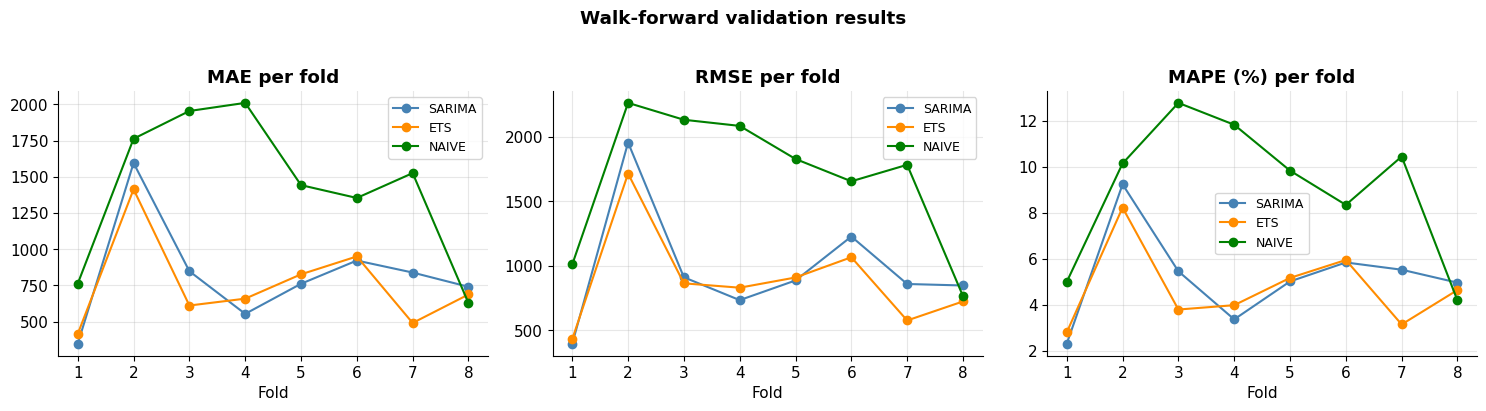

In [ ]:
# ---------- Results summary table ----------
summary = pd.DataFrame({
    'Model': ['SARIMA', 'ETS', 'Seasonal Naïve'],
    'MAE':  [
        wf_results['sarima_mae'].mean(),
        wf_results['ets_mae'].mean(),
        wf_results['naive_mae'].mean()
    ],
    'RMSE': [
        wf_results['sarima_rmse'].mean(),
        wf_results['ets_rmse'].mean(),
        wf_results['naive_rmse'].mean()
    ],
    'MAPE (%)': [
        wf_results['sarima_mape'].mean(),
        wf_results['ets_mape'].mean(),
        wf_results['naive_mape'].mean()
    ]
})
summary = summary.set_index('Model').round(2)
print("\n=== Walk-Forward CV Results (8-fold, 7-day horizon) ===")
print(summary.to_string())

# Visualise MAE per fold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('mae', 'MAE'), ('rmse', 'RMSE'), ('mape', 'MAPE (%)')]
colors  = {'sarima': 'steelblue', 'ets': 'darkorange', 'naive': 'green'}

for ax, (metric, label) in zip(axes, metrics):
    for model in ['sarima', 'ets', 'naive']:
        ax.plot(
            wf_results['fold'],
            wf_results[f'{model}_{metric}'],
            marker='o', label=model.upper(),
            color=colors[model], linewidth=1.5
        )
    ax.set_title(f'{label} per fold', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.legend(fontsize=9)

plt.suptitle('Walk-forward validation results', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Residual diagnostics

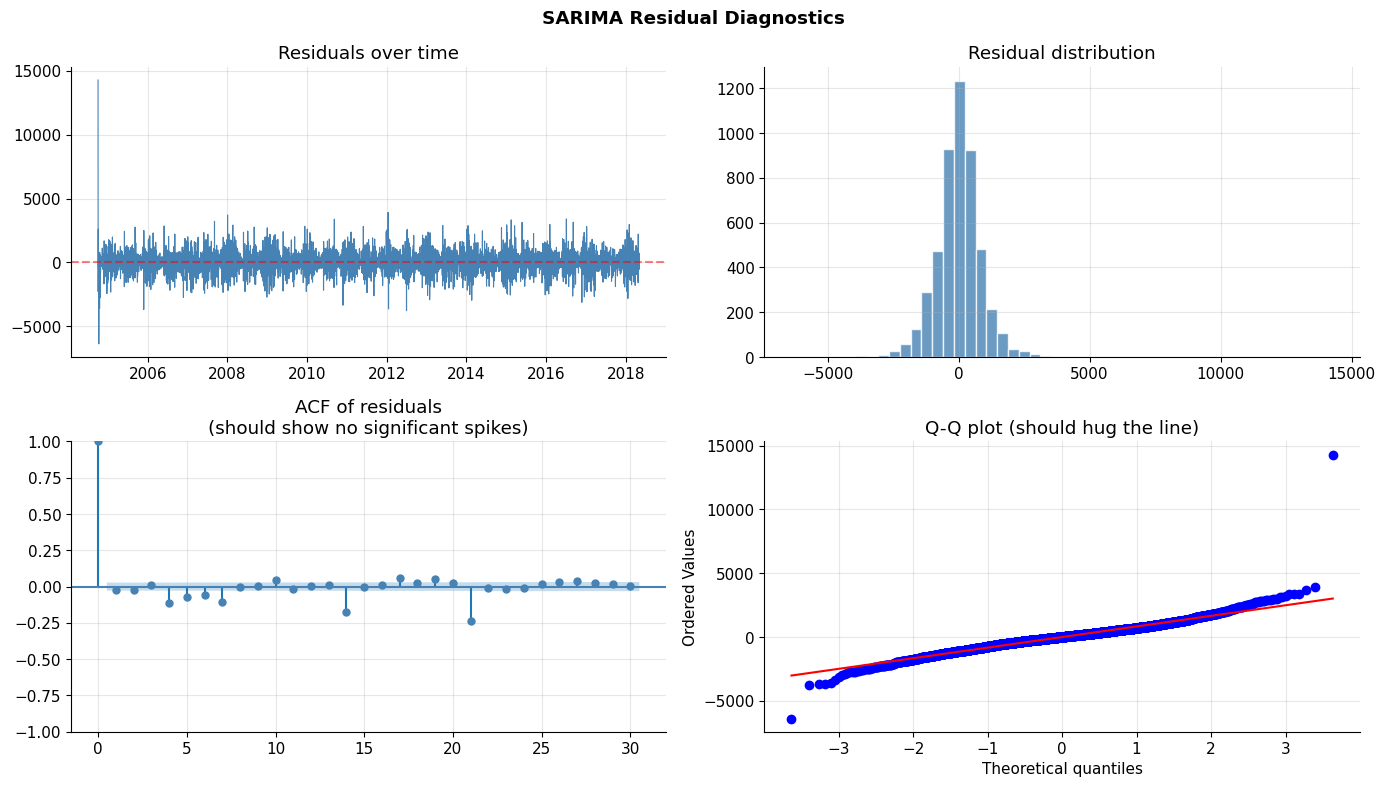


Ljung-Box test (H0: residuals are white noise)
p-value > 0.05 → no significant autocorrelation remaining ✅
       lb_stat      lb_pvalue
7   158.850060   5.599846e-31
14  325.902319   4.596331e-61
21  648.330338  1.065800e-123


In [ ]:
# ---------- SARIMA residuals ----------
sarima_resid = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0, 0].plot(sarima_resid, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals over time')

# Residual distribution
axes[0, 1].hist(sarima_resid, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Residual distribution')

# ACF of residuals
plot_acf(sarima_resid.dropna(), lags=30, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ACF of residuals\n(should show no significant spikes)')

# Q-Q plot
from scipy import stats
stats.probplot(sarima_resid.dropna(), plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot (should hug the line)')

plt.suptitle('SARIMA Residual Diagnostics', fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- Ljung-Box test ----------
lb_result = acorr_ljungbox(sarima_resid.dropna(), lags=[7, 14, 21], return_df=True)
print("\nLjung-Box test (H0: residuals are white noise)")
print("p-value > 0.05 → no significant autocorrelation remaining ✅")
print(lb_result)

# --- Study note ---
# If you see significant spikes in residual ACF at lag 7, 14, 365:
#   → your model missed some seasonal structure → add D=1 or increase P/Q
# If residuals have a trend: → your model missed trend → add d=1 or use trend='add' in ETS

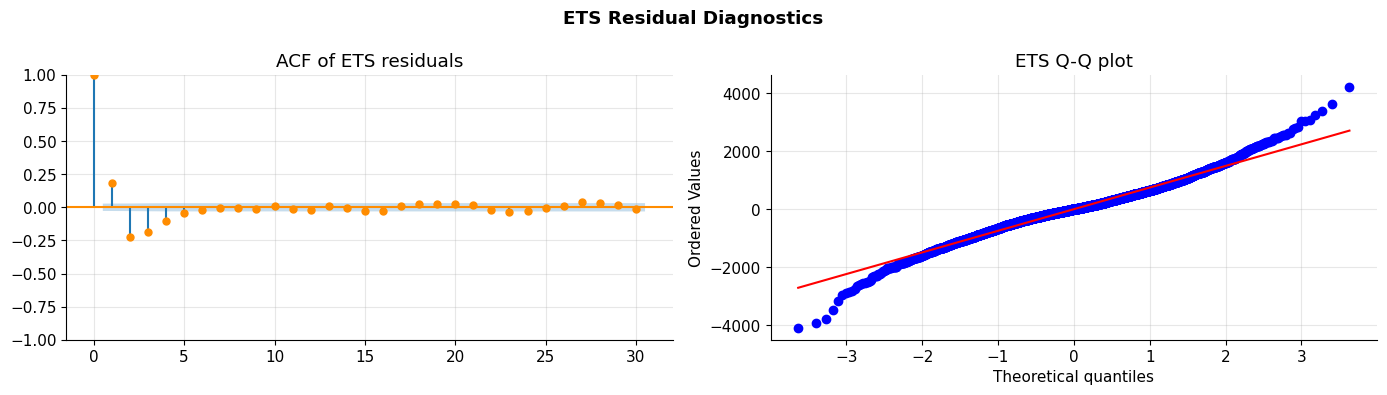


ETS Ljung-Box test:
       lb_stat      lb_pvalue
7   660.585074  2.161395e-138
14  666.828083  3.080030e-133
21  687.157066  6.851573e-132


In [ ]:
# ---------- ETS residuals ----------
ets_resid = ets_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ets_resid.dropna(), lags=30, ax=axes[0], color='darkorange')
axes[0].set_title('ACF of ETS residuals')

from scipy import stats
stats.probplot(ets_resid.dropna(), plot=axes[1])
axes[1].set_title('ETS Q-Q plot')

plt.suptitle('ETS Residual Diagnostics', fontweight='bold')
plt.tight_layout()
plt.show()

lb_ets = acorr_ljungbox(ets_resid.dropna(), lags=[7, 14, 21], return_df=True)
print("\nETS Ljung-Box test:")
print(lb_ets)

---
## 7. SARIMA prediction intervals

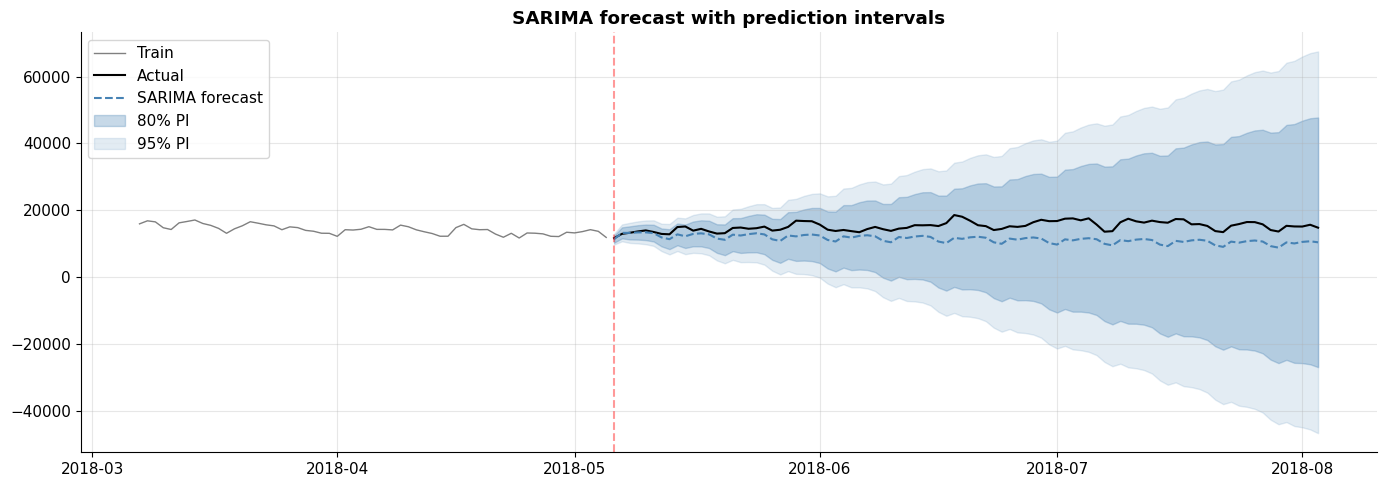

95% PI coverage: 100.0%  (should be ~95%)


In [ ]:
# SARIMA gives prediction intervals natively
forecast_obj = sarima_fit.get_forecast(steps=TEST_DAYS)
fc_mean  = forecast_obj.predicted_mean
fc_ci_80 = forecast_obj.conf_int(alpha=0.20)   # 80% interval
fc_ci_95 = forecast_obj.conf_int(alpha=0.05)   # 95% interval

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-60:], color='gray', linewidth=1, label='Train')
ax.plot(test, color='black', linewidth=1.5, label='Actual')
ax.plot(fc_mean, color='steelblue', linewidth=1.5, linestyle='--', label='SARIMA forecast')

ax.fill_between(
    fc_ci_80.index,
    fc_ci_80.iloc[:, 0], fc_ci_80.iloc[:, 1],
    alpha=0.3, color='steelblue', label='80% PI'
)
ax.fill_between(
    fc_ci_95.index,
    fc_ci_95.iloc[:, 0], fc_ci_95.iloc[:, 1],
    alpha=0.15, color='steelblue', label='95% PI'
)

ax.axvline(test.index[0], color='red', linestyle='--', alpha=0.4)
ax.set_title('SARIMA forecast with prediction intervals', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Coverage check: what % of actuals fall inside the 95% interval?
inside_95 = (
    (test.values >= fc_ci_95.iloc[:, 0].values) &
    (test.values <= fc_ci_95.iloc[:, 1].values)
).mean() * 100
print(f"95% PI coverage: {inside_95:.1f}%  (should be ~95%)")
# --- Study note ---
# If coverage < 95%, the model is overconfident — intervals too narrow
# This is common when residuals are not normally distributed

---
## 8. Where classical models break down → Motivation for Phase 3

Run this cell to identify specific failure modes that LightGBM (Phase 3) will fix.

Top 10 worst SARIMA forecast days:
                  actual   sarima_pred  sarima_error day_of_week  month
Datetime                                                               
2018-07-01  16798.791667   9756.100471   7042.691196      Sunday      7
2018-07-15  16296.208333   9300.334186   6995.874147      Sunday      7
2018-06-18  18590.750000  11781.417674   6809.332326      Monday      6
2018-07-17  17311.125000  10549.605153   6761.519847     Tuesday      7
2018-07-14  16488.375000   9750.978211   6737.396789    Saturday      7
2018-07-10  17489.333333  10780.443157   6708.890176     Tuesday      7
2018-06-19  18086.583333  11471.113217   6615.470116     Tuesday      6
2018-07-03  17590.166667  11016.399014   6573.767653     Tuesday      7
2018-06-30  16760.291667  10203.780312   6556.511354    Saturday      6
2018-07-16  17400.041667  10867.652635   6532.389032      Monday      7


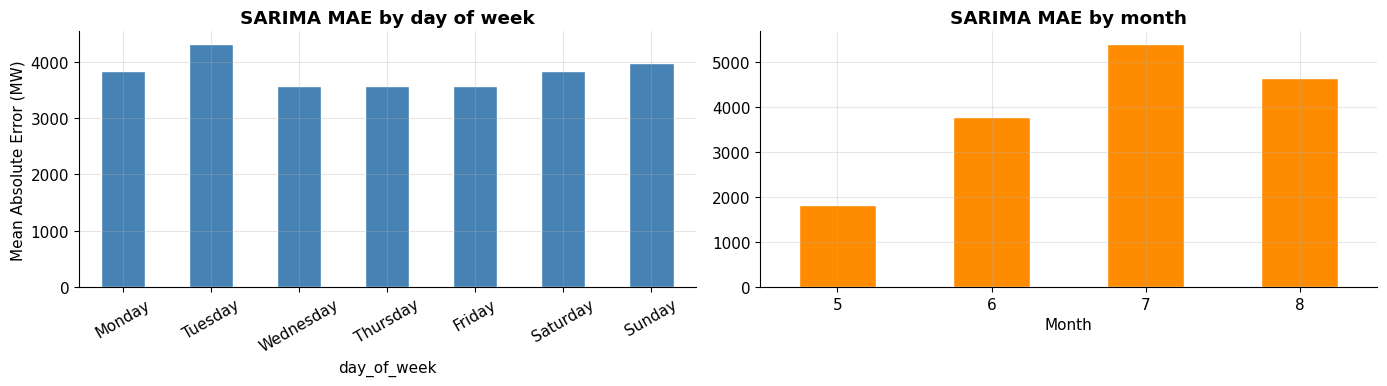


╔══════════════════════════════════════════════════════════════╗
║           Classical model failure modes — write these down  ║
╠══════════════════════════════════════════════════════════════╣
║  ❌  Multi-seasonality: daily + weekly + annual can't all   ║
║      fit in one SARIMA                                       ║
║  ❌  Holidays: SARIMA has no concept of 'this is a holiday' ║
║  ❌  Weather: temperature drives demand — SARIMA ignores it  ║
║  ❌  Long horizons: accuracy degrades after ~7 days          ║
║  ❌  Refitting cost: SARIMA must refit for each new series   ║
║                                                              ║
║  → Phase 3 (LightGBM) fixes all of these via feature        ║
║    engineering: lag features, calendar features, weather     ║
╚══════════════════════════════════════════════════════════════╝



In [ ]:
# ---------- Error analysis: find the worst forecast days ----------
errors_df = pd.DataFrame({
    'actual':      test.values,
    'sarima_pred': sarima_forecast.values,
    'ets_pred':    ets_forecast.values,
    'day_of_week': test.index.day_name(),
    'month':       test.index.month,
}, index=test.index)

errors_df['sarima_error'] = (errors_df['actual'] - errors_df['sarima_pred']).abs()
errors_df['ets_error']    = (errors_df['actual'] - errors_df['ets_pred']).abs()

# Top 10 worst SARIMA days
print("Top 10 worst SARIMA forecast days:")
print(errors_df.nlargest(10, 'sarima_error')[['actual','sarima_pred','sarima_error','day_of_week','month']])

# Error by day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

errors_df.groupby('day_of_week')['sarima_error'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('SARIMA MAE by day of week', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error (MW)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

errors_df.groupby('month')['sarima_error'].mean().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white'
)
axes[1].set_title('SARIMA MAE by month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("""
╔══════════════════════════════════════════════════════════════╗
║           Classical model failure modes — write these down  ║
╠══════════════════════════════════════════════════════════════╣
║  ❌  Multi-seasonality: daily + weekly + annual can't all   ║
║      fit in one SARIMA                                       ║
║  ❌  Holidays: SARIMA has no concept of 'this is a holiday' ║
║  ❌  Weather: temperature drives demand — SARIMA ignores it  ║
║  ❌  Long horizons: accuracy degrades after ~7 days          ║
║  ❌  Refitting cost: SARIMA must refit for each new series   ║
║                                                              ║
║  → Phase 3 (LightGBM) fixes all of these via feature        ║
║    engineering: lag features, calendar features, weather     ║
╚══════════════════════════════════════════════════════════════╝
""")

---
## ✅ Project checklist

Before moving to Phase 3, make sure you can answer these:

- [ ] What does `d=1` mean in SARIMA and why did we apply it?
- [ ] How did you choose `p`, `q`, `P`, `Q` from the ACF/PACF plots?
- [ ] Why is walk-forward validation different from random K-fold CV?
- [ ] What does the Ljung-Box test tell you? Was your model's result good?
- [ ] Did ETS or SARIMA win on your walk-forward results? Why do you think that is?
- [ ] What are the 3 biggest failure modes of your SARIMA model?
- [ ] Write one sentence: **what problem does Phase 3 solve that Phase 2 cannot?**

---
*Next: Phase 3 — LightGBM energy forecaster with lag + calendar + weather features*